# Analysis of the \(\alpha_2\)-\(\beta_2\) two-family structure

This notebook loads `dataframe000013.pkl` and `dataframe000014.pkl`, keeps the **top 5 overall** solutions for each independent dataset and each `(mass, lattice parameter)` pair, and analyzes the apparent two-family structure in the second-nearest-neighbor force constants \(\alpha_2\) and \(\beta_2\).

The analysis includes:

1. Scatter plots of \(\beta_2\) vs. \(\alpha_2\) colored by lattice parameter, mass, and \(\alpha_1\).
2. Derived variables that quantify the relative dominance of \(\alpha_2\) or \(\beta_2\).
3. A simple family classification based on whether \(|\alpha_2|\) or \(|\beta_2|\) dominates.
4. Summary statistics by family.
5. Pairwise plots that use the derived family variable as color.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%config InlineBackend.figure_format = "retina"

# -----------------------------------------------------------------------------
# User settings
# -----------------------------------------------------------------------------

DATA_DIR = Path("./dataframes/")  # Update if needed.

DATAFRAME_FILES = {
    "dataframe000013": DATA_DIR / "dataframe000013.pkl",
    "dataframe000014": DATA_DIR / "dataframe000014.pkl",
    "dataframe000015": DATA_DIR / "dataframe000015.pkl",
    "dataframe000016": DATA_DIR / "dataframe000016.pkl",
    
}

OUTPUT_DIR = Path("alpha2_beta2_family_analysis_top5_overall")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_K = 5
RANK_BY = "fitness_norm"

SAVE_FORMATS = ("pdf", "png")
DPI = 300

FIGSIZE = (5.8, 4.8)
MARKER_SIZE = 50
MARKER_ALPHA = 0.85
EDGE_WIDTH = 0.25

# Threshold used to identify points close to zero.
# This is only for descriptive classification. You can tune it.
ZERO_TOL = 0.08


In [2]:
def find_first_existing(candidates, columns):
    for col in candidates:
        if col in columns:
            return col
    return None


def load_dataframe(path, dataset_label):
    if not path.exists():
        raise FileNotFoundError(
            f"Could not find {path}. Update DATA_DIR or DATAFRAME_FILES at the top of the notebook."
        )
    df = pd.read_pickle(path).copy()
    df["dataset"] = dataset_label
    return df


def display_label(col):
    label_map = {
        "mass": r"$m$ (amu)", "m": r"$m$ (amu)",
        "a_val": r"$a$ ($\AA$)", "alat": r"$a$ ($\AA$)",
        "a_latt": r"$a$ ($\AA$)", "lattice_parameter": r"$a$ ($\AA$)",
        "alpha0": r"$\alpha_0$ (N/m)", "alpha_0": r"$\alpha_0$ (N/m)",
        "alpha1": r"$\alpha_1$ (N/m)", "alpha_1": r"$\alpha_1$ (N/m)",
        "beta1": r"$\beta_1$ (N/m)", "beta_1": r"$\beta_1$ (N/m)",
        "alpha2": r"$\alpha_2$ (N/m)", "alpha_2": r"$\alpha_2$ (N/m)",
        "beta2": r"$\beta_2$ (N/m)", "beta_2": r"$\beta_2$ (N/m)",
        "fitness2": r"$f_2$", "f2": r"$f_2$",
        "fitness3": r"$f_3$", "f3": r"$f_3$",
        "fitness_norm": r"$f_{\mathrm{norm}}$", "fnorm": r"$f_{\mathrm{norm}}$",
        "min_frequency": r"$\omega_{\min}$ (THz)", "min_freq": r"$\omega_{\min}$ (THz)",
        "max_frequency": r"$\omega_{\max}$ (THz)", "max_freq": r"$\omega_{\max}$ (THz)",
        "num_imaginary": r"$N_-$", "n_imaginary": r"$N_-$",
        "r_alpha2": r"$r_{\alpha_2}$",
        "delta_alpha2_beta2": r"$|\alpha_2|-|\beta_2|$",
        "family_code": "Family code",
    }
    return label_map.get(col, col)


def safe_token(name):
    return (
        str(name).replace("\\", "").replace("$", "").replace("{", "").replace("}", "")
        .replace("^", "").replace("_", "").replace(" ", "_").replace("/", "_")
    )


def apply_publication_axes(ax):
    ax.tick_params(
        axis="both",
        which="both",
        direction="in",
        top=True,
        right=True,
        labelsize=12,
        length=5,
        width=1.1,
    )
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.1)


def save_figure(fig, stem, output_dir=OUTPUT_DIR, formats=SAVE_FORMATS):
    output_dir.mkdir(parents=True, exist_ok=True)
    saved = []
    for ext in formats:
        outpath = output_dir / f"{stem}.{ext}"
        fig.savefig(outpath, dpi=DPI, bbox_inches="tight")
        saved.append(outpath)
    print("Saved:")
    for path in saved:
        print(f"  {path}")
    return saved


In [3]:
# -----------------------------------------------------------------------------
# Load and aggregate dataframes
# -----------------------------------------------------------------------------

frames = []
for label, path in DATAFRAME_FILES.items():
    tmp = load_dataframe(path, label)
    print(f"{label}: {tmp.shape[0]:,} rows, {tmp.shape[1]:,} columns")
    frames.append(tmp)

df_all = pd.concat(frames, ignore_index=True)
print(f"\nAggregated dataframe before filtering: {df_all.shape[0]:,} rows, {df_all.shape[1]:,} columns")
df_all.head()


dataframe000013: 105,000 rows, 35 columns
dataframe000014: 105,000 rows, 35 columns
dataframe000015: 105,000 rows, 35 columns
dataframe000016: 105,000 rows, 35 columns

Aggregated dataframe before filtering: 420,000 rows, 35 columns


,simulation,generation,solution_index,rank,source,timestamp,mass,a_val,system_size,alpha0,...,gamma_frequencies,distances,qpoints,frequencies,frequency_vector,simulation_path,generation_dir,solution_dir,band_yaml_path,dataset
0,simulation000588,1,5,0,population,2026-05-22T19:33:42.238245,50.0,2.0,5,5.607430,...,"[0.8275024, 0.8275024, 0.8275024]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[0.8275024, 0.8275024, 0.8275024], [0.8291954...","[0.8275024, 0.8275024, 0.8275024, 0.8291954, 0...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
1,simulation000588,1,92,1,population,2026-05-22T19:33:42.238245,50.0,2.0,5,6.189523,...,"[1.562392, 1.562392, 1.562392]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[1.562392, 1.562392, 1.562392], [1.563087, 1....","[1.562392, 1.562392, 1.562392, 1.563087, 1.563...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
2,simulation000588,1,44,2,population,2026-05-22T19:33:42.238245,50.0,2.0,5,3.931578,...,"[-1.0034583, -1.0034583, -1.0034583]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-1.0034583, -1.0034583, -1.0034583], [-1.002...","[-1.0034583, -1.0034583, -1.0034583, -1.002285...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
3,simulation000588,1,155,3,population,2026-05-22T19:33:42.238245,50.0,2.0,5,6.349680,...,"[1.0862614, 1.0862614, 1.0862614]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[1.0862614, 1.0862614, 1.0862614], [1.0880687...","[1.0862614, 1.0862614, 1.0862614, 1.0880687, 1...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013
4,simulation000588,1,125,4,population,2026-05-22T19:33:42.238245,50.0,2.0,5,8.587408,...,"[-1.2866693, -1.2866693, -1.2866693]","[0.0, 0.0025, 0.005, 0.0075, 0.01, 0.0125, 0.0...","[[0.0, 0.0, 0.0], [-0.0025, 0.0025, 0.0025], [...","[[-1.2866693, -1.2866693, -1.2866693], [-1.284...","[-1.2866693, -1.2866693, -1.2866693, -1.284834...",simulations/simulation000588,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,simulations/simulation000588/phonon_generation...,dataframe000013


In [4]:
# -----------------------------------------------------------------------------
# Detect relevant columns
# -----------------------------------------------------------------------------

mass_col = find_first_existing(["mass", "m"], df_all.columns)
alat_col = find_first_existing(["a_val", "alat", "a_latt", "lattice_parameter"], df_all.columns)
alpha1_col = find_first_existing(["alpha1", "alpha_1"], df_all.columns)
alpha2_col = find_first_existing(["alpha2", "alpha_2"], df_all.columns)
beta2_col = find_first_existing(["beta2", "beta_2"], df_all.columns)
rank_col = find_first_existing([RANK_BY, "fitness_norm", "fnorm"], df_all.columns)

required = {
    "mass": mass_col,
    "lattice parameter": alat_col,
    "alpha1": alpha1_col,
    "alpha2": alpha2_col,
    "beta2": beta2_col,
    "ranking": rank_col,
}

for name, col in required.items():
    if col is None:
        raise ValueError(f"Could not find required column for {name}.")

for name, col in required.items():
    print(f"{name:20s}: {col}")


mass                : mass
lattice parameter   : a_val
alpha1              : alpha1
alpha2              : alpha2
beta2               : beta2
ranking             : fitness_norm


In [5]:
# -----------------------------------------------------------------------------
# Select top 5 overall per dataset, mass, and lattice parameter
# -----------------------------------------------------------------------------

df_top = (
    df_all.sort_values(rank_col, ascending=False)
    .groupby(["dataset", mass_col, alat_col], group_keys=False)
    .head(TOP_K)
    .copy()
)

# Convert key columns to numeric.
for col in [mass_col, alat_col, alpha1_col, alpha2_col, beta2_col, rank_col]:
    df_top[col] = pd.to_numeric(df_top[col], errors="coerce")

df_top = df_top.dropna(subset=[mass_col, alat_col, alpha1_col, alpha2_col, beta2_col, rank_col]).copy()

print(f"Rows after top-{TOP_K}-overall selection and cleanup: {df_top.shape[0]:,}")
df_top[["dataset", mass_col, alat_col, alpha1_col, alpha2_col, beta2_col, rank_col]].head()


Rows after top-5-overall selection and cleanup: 840


,dataset,mass,a_val,alpha1,alpha2,beta2,fitness_norm
214621,dataframe000015,50.0,2.2,-0.321338,0.000162,-0.650614,1.731862
214938,dataframe000015,50.0,2.2,-0.321338,0.000162,-0.650614,1.731862
214926,dataframe000015,50.0,2.2,-0.321338,0.000162,-0.650614,1.731862
214927,dataframe000015,50.0,2.2,-0.321338,0.000162,-0.650614,1.731862
214928,dataframe000015,50.0,2.2,-0.321338,0.000162,-0.650614,1.731862


In [6]:
# -----------------------------------------------------------------------------
# Derived variables for the two-family analysis
# -----------------------------------------------------------------------------

eps = 1e-12

df_top["abs_alpha2"] = df_top[alpha2_col].abs()
df_top["abs_beta2"] = df_top[beta2_col].abs()

# Ratio close to 1 means alpha2-dominated; close to 0 means beta2-dominated.
df_top["r_alpha2"] = df_top["abs_alpha2"] / (df_top["abs_alpha2"] + df_top["abs_beta2"] + eps)

# Positive means |alpha2| dominates; negative means |beta2| dominates.
df_top["delta_alpha2_beta2"] = df_top["abs_alpha2"] - df_top["abs_beta2"]

# Product near zero indicates one of the two parameters is close to zero.
df_top["alpha2_beta2_product"] = df_top[alpha2_col] * df_top[beta2_col]

def classify_family(row):
    a2 = row[alpha2_col]
    b2 = row[beta2_col]
    abs_a2 = abs(a2)
    abs_b2 = abs(b2)

    if abs_a2 <= ZERO_TOL and abs_b2 <= ZERO_TOL:
        return "both near zero"
    if abs_b2 <= ZERO_TOL and abs_a2 > ZERO_TOL:
        return r"$\alpha_2$-dominated"
    if abs_a2 <= ZERO_TOL and abs_b2 > ZERO_TOL:
        return r"$\beta_2$-dominated"
    if abs_a2 > abs_b2:
        return r"$\alpha_2$ larger"
    if abs_b2 > abs_a2:
        return r"$\beta_2$ larger"
    return "balanced"

df_top["family"] = df_top.apply(classify_family, axis=1)

family_order = [
    r"$\alpha_2$-dominated",
    r"$\beta_2$-dominated",
    r"$\alpha_2$ larger",
    r"$\beta_2$ larger",
    "both near zero",
    "balanced",
]

family_to_code = {fam: i for i, fam in enumerate(family_order)}
df_top["family_code"] = df_top["family"].map(family_to_code)

print(df_top["family"].value_counts())
df_top[["dataset", mass_col, alat_col, alpha1_col, alpha2_col, beta2_col, "r_alpha2", "delta_alpha2_beta2", "family"]].head()


family
$\beta_2$-dominated     600
$\alpha_2$-dominated    205
both near zero           35
Name: count, dtype: int64


,dataset,mass,a_val,alpha1,alpha2,beta2,r_alpha2,delta_alpha2_beta2,family
214621,dataframe000015,50.0,2.2,-0.321338,0.000162,-0.650614,0.000249,-0.650452,$\beta_2$-dominated
214938,dataframe000015,50.0,2.2,-0.321338,0.000162,-0.650614,0.000249,-0.650452,$\beta_2$-dominated
214926,dataframe000015,50.0,2.2,-0.321338,0.000162,-0.650614,0.000249,-0.650452,$\beta_2$-dominated
214927,dataframe000015,50.0,2.2,-0.321338,0.000162,-0.650614,0.000249,-0.650452,$\beta_2$-dominated
214928,dataframe000015,50.0,2.2,-0.321338,0.000162,-0.650614,0.000249,-0.650452,$\beta_2$-dominated


In [7]:
# -----------------------------------------------------------------------------
# Summary statistics by family
# -----------------------------------------------------------------------------

summary_cols = [
    mass_col,
    alat_col,
    alpha1_col,
    alpha2_col,
    beta2_col,
    rank_col,
    "r_alpha2",
    "delta_alpha2_beta2",
    "alpha2_beta2_product",
]

summary = (
    df_top.groupby("family")[summary_cols]
    .agg(["count", "mean", "std", "min", "max"])
)

summary


mass                                    a_val            \
                     count       mean        std   min    max count      mean   
family                                                                          
$\alpha_2$-dominated   205  73.658539  17.114965  50.0  100.0   205  2.653659   
$\beta_2$-dominated    600  75.500000  17.085175  50.0  100.0   600  2.583333   
both near zero          35  74.285713  17.026918  60.0  100.0    35  2.571429   

                                          ... delta_alpha2_beta2            \
                           std  min  max  ...              count      mean   
family                                    ...                                
$\alpha_2$-dominated  0.370544  2.0  3.2  ...                205  1.098844   
$\beta_2$-dominated   0.410695  2.0  3.2  ...                600 -1.050170   
both near zero        0.366679  2.0  3.2  ...                 35 -0.011117   

                                                   alpha2_beta2_product  \
                           std       min       max                count   
family                                                                    
$\alpha_2$-dominated  0.515746  0.141103  1.993884                  205   
$\beta_2$-dominated   0.449012 -1.987556 -0.128238                  600   
both near zero        0.033979 -0.068514  0.041886                   35   

                                                                  
                              mean       std       min       max  
family                                                            
$\alpha_2$-dominated -1.844469e-04  0.000997 -0.003313  0.003703  
$\beta_2$-dominated  -5.599366e-05  0.001238 -0.004647  0.003799  
both near zero       -7.961106e-07  0.000029 -0.000062  0.000037  

[3 rows x 45 columns]

In [8]:
def scatter_alpha2_beta2(color_col, cmap, stem, title_suffix=None):
    """
    Scatter plot of beta2 vs alpha2 colored by a chosen variable.
    Dataset identity is shown by marker shape.
    """
    fig, ax = plt.subplots(figsize=FIGSIZE)

    c_all = df_top[color_col].astype(float)
    markers = {
        "dataframe000013": "o",
        "dataframe000014": "s",
    }

    scatter_ref = None

    for dataset_label, sub in df_top.groupby("dataset"):
        marker = markers.get(dataset_label, "o")
        sc = ax.scatter(
            sub[alpha2_col],
            sub[beta2_col],
            c=sub[color_col],
            cmap=cmap,
            vmin=c_all.min(),
            vmax=c_all.max(),
            s=MARKER_SIZE,
            alpha=MARKER_ALPHA,
            edgecolors="black",
            linewidths=EDGE_WIDTH,
            marker=marker,
            label=dataset_label,
        )
        scatter_ref = sc

    ax.axhline(0, color="0.35", linewidth=0.9, zorder=0)
    ax.axvline(0, color="0.35", linewidth=0.9, zorder=0)

    ax.set_xlabel(display_label(alpha2_col), fontsize=14)
    ax.set_ylabel(display_label(beta2_col), fontsize=14)

    if title_suffix is None:
        title_suffix = display_label(color_col)
    ax.set_title(r"$\beta_2$ vs. $\alpha_2$ colored by " + title_suffix, fontsize=15, pad=10)

    apply_publication_axes(ax)

    cbar = fig.colorbar(scatter_ref, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(display_label(color_col), fontsize=13)
    cbar.ax.tick_params(labelsize=11)

    ax.legend(frameon=False, fontsize=9, loc="best")

    fig.tight_layout()
    saved = save_figure(fig, stem)

    plt.show()
    return fig, ax, saved


Saved:
  alpha2_beta2_family_analysis_top5_overall/beta2_vs_alpha2_colored_by_lattice_parameter.pdf
  alpha2_beta2_family_analysis_top5_overall/beta2_vs_alpha2_colored_by_lattice_parameter.png


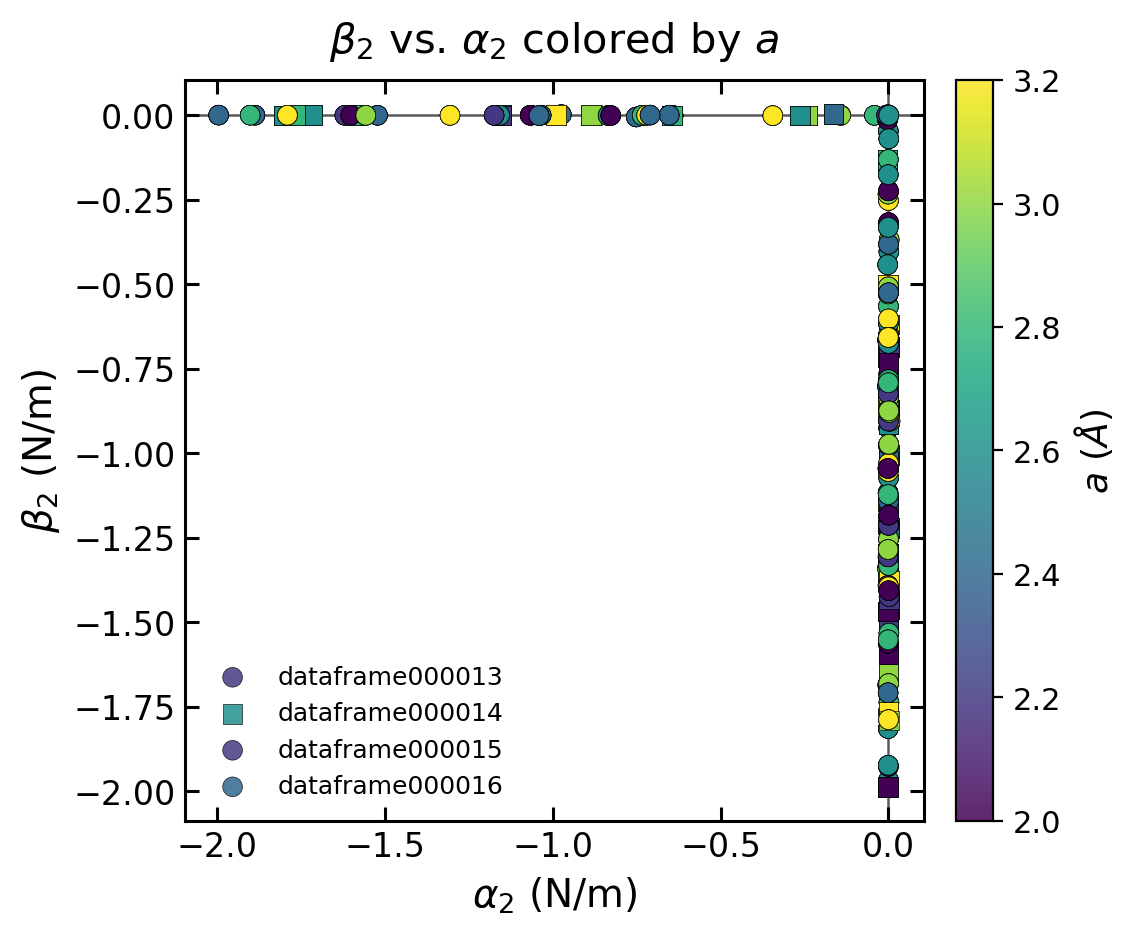

Saved:
  alpha2_beta2_family_analysis_top5_overall/beta2_vs_alpha2_colored_by_mass.pdf
  alpha2_beta2_family_analysis_top5_overall/beta2_vs_alpha2_colored_by_mass.png


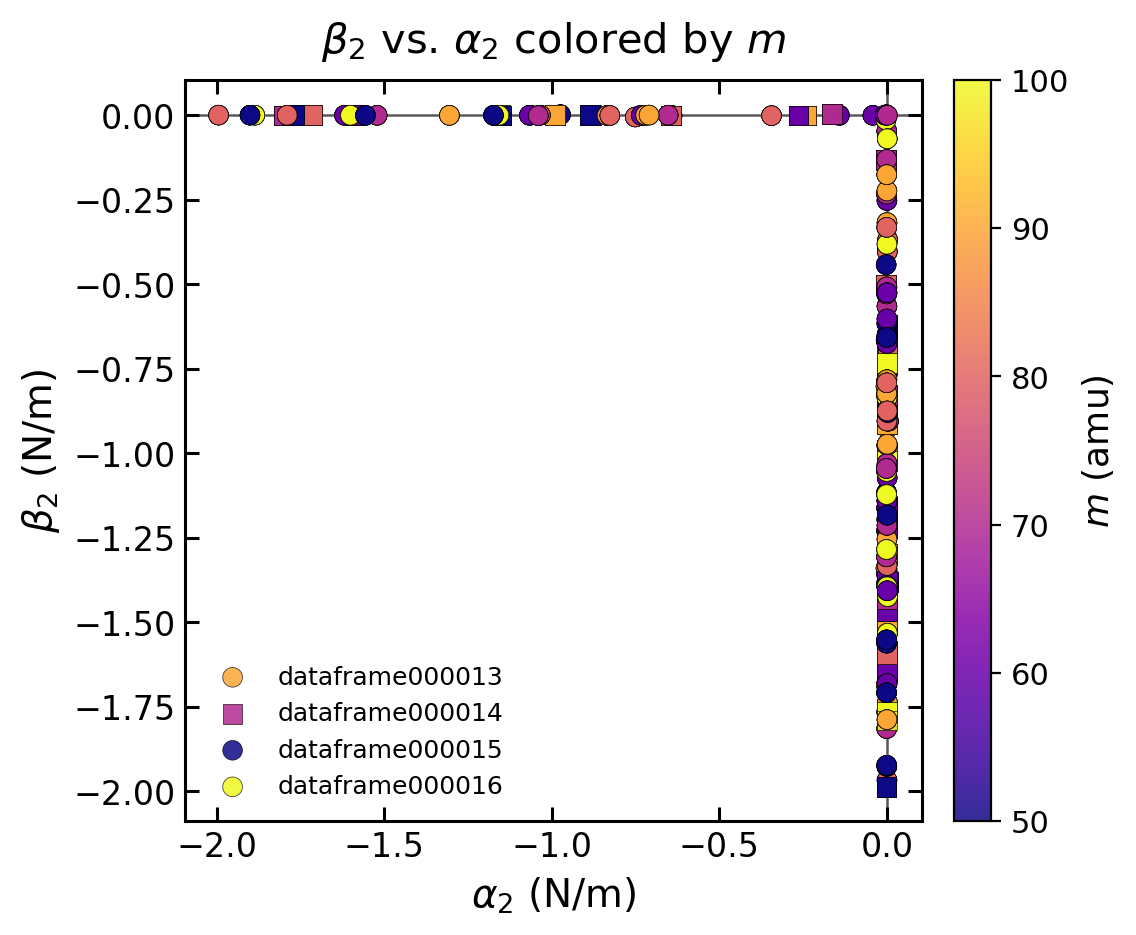

Saved:
  alpha2_beta2_family_analysis_top5_overall/beta2_vs_alpha2_colored_by_alpha1.pdf
  alpha2_beta2_family_analysis_top5_overall/beta2_vs_alpha2_colored_by_alpha1.png


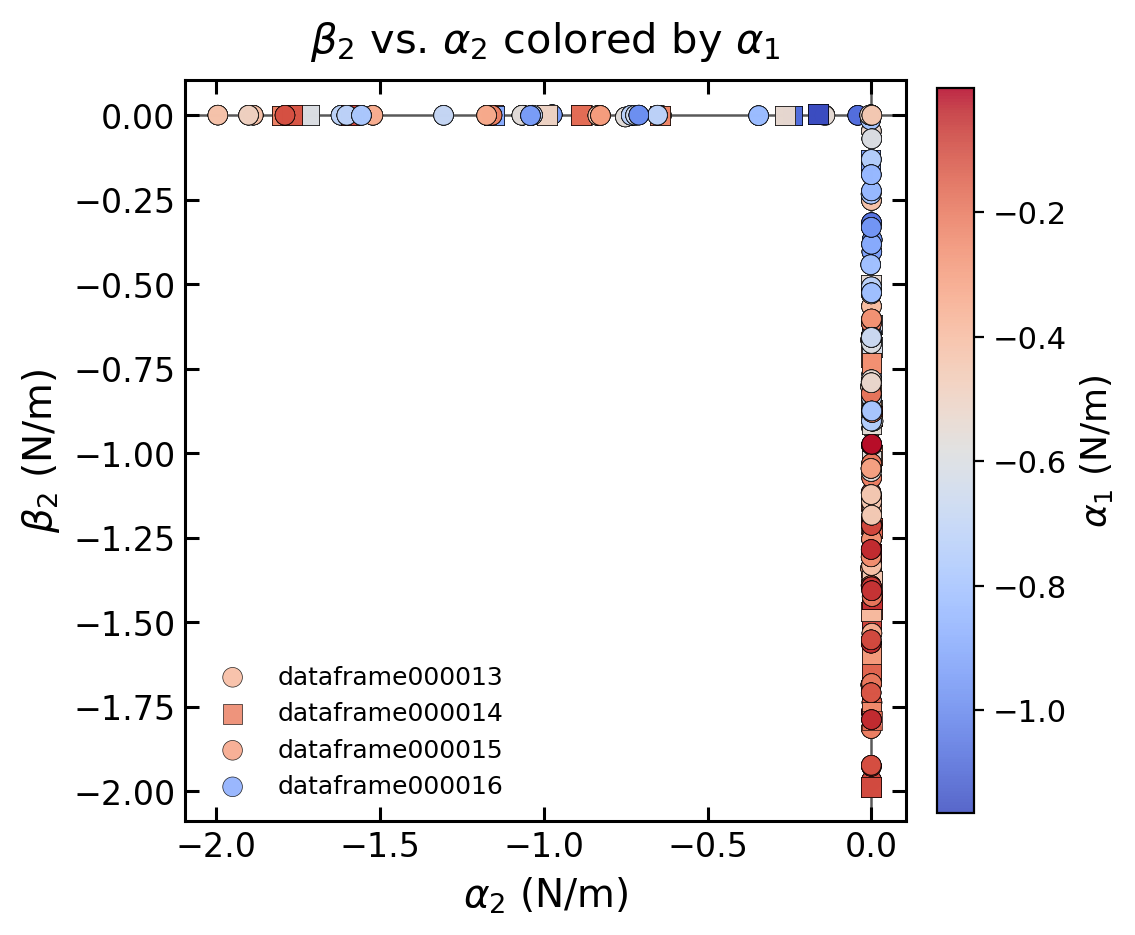

(<Figure size 580x480 with 2 Axes>,
 <Axes: title={'center': '$\\beta_2$ vs. $\\alpha_2$ colored by $\\alpha_1$'}, xlabel='$\\alpha_2$ (N/m)', ylabel='$\\beta_2$ (N/m)'>,
 [PosixPath('alpha2_beta2_family_analysis_top5_overall/beta2_vs_alpha2_colored_by_alpha1.pdf'),
  PosixPath('alpha2_beta2_family_analysis_top5_overall/beta2_vs_alpha2_colored_by_alpha1.png')])

In [9]:
# Scatter plots requested and discussed.

scatter_alpha2_beta2(
    color_col=alat_col,
    cmap="viridis",
    stem="beta2_vs_alpha2_colored_by_lattice_parameter",
    title_suffix=r"$a$",
)

scatter_alpha2_beta2(
    color_col=mass_col,
    cmap="plasma",
    stem="beta2_vs_alpha2_colored_by_mass",
    title_suffix=r"$m$",
)

scatter_alpha2_beta2(
    color_col=alpha1_col,
    cmap="coolwarm",
    stem="beta2_vs_alpha2_colored_by_alpha1",
    title_suffix=r"$\alpha_1$",
)


Saved:
  alpha2_beta2_family_analysis_top5_overall/beta2_vs_alpha2_colored_by_r_alpha2.pdf
  alpha2_beta2_family_analysis_top5_overall/beta2_vs_alpha2_colored_by_r_alpha2.png


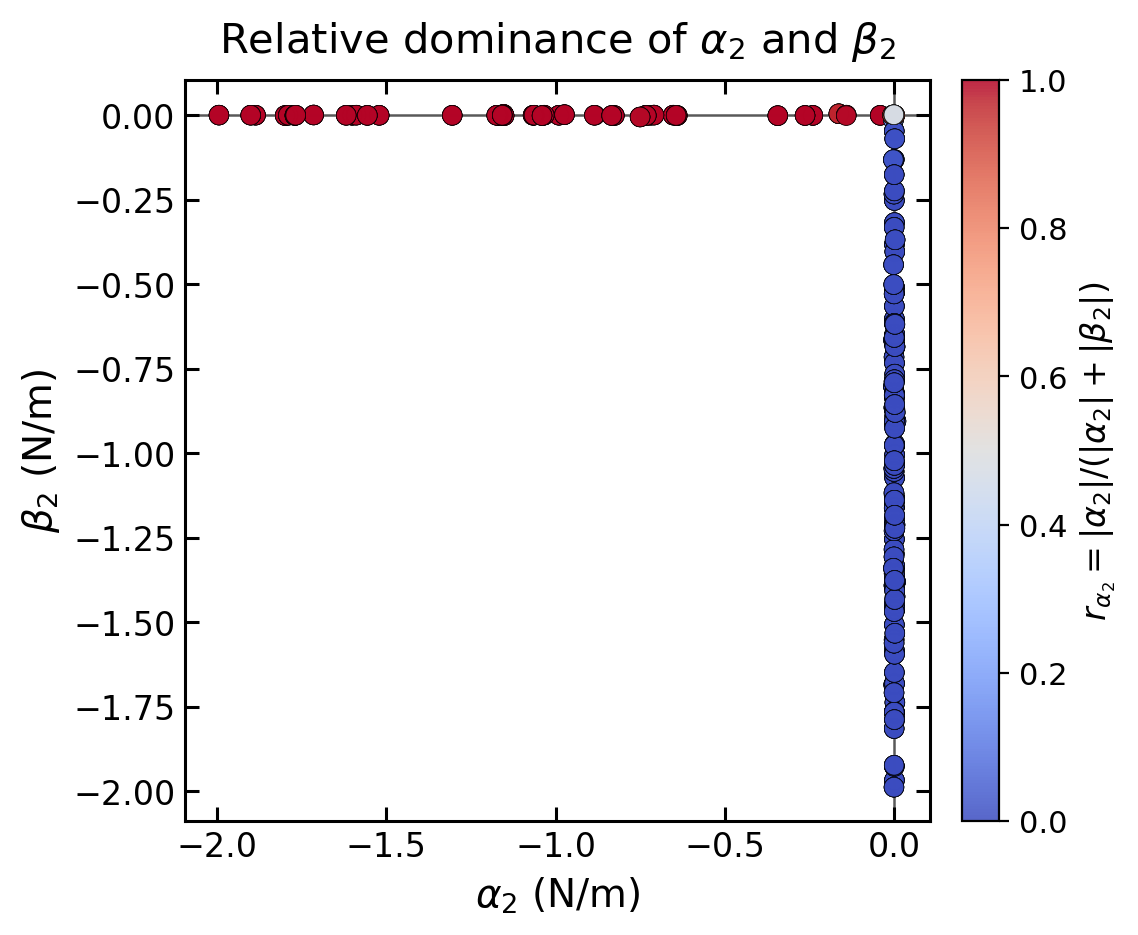

In [10]:
# -----------------------------------------------------------------------------
# Plot the derived alpha2-dominance ratio in the alpha2-beta2 plane
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=FIGSIZE)

sc = ax.scatter(
    df_top[alpha2_col],
    df_top[beta2_col],
    c=df_top["r_alpha2"],
    cmap="coolwarm",
    vmin=0,
    vmax=1,
    s=MARKER_SIZE,
    alpha=MARKER_ALPHA,
    edgecolors="black",
    linewidths=EDGE_WIDTH,
)

ax.axhline(0, color="0.35", linewidth=0.9, zorder=0)
ax.axvline(0, color="0.35", linewidth=0.9, zorder=0)

ax.set_xlabel(display_label(alpha2_col), fontsize=14)
ax.set_ylabel(display_label(beta2_col), fontsize=14)
ax.set_title(r"Relative dominance of $\alpha_2$ and $\beta_2$", fontsize=15, pad=10)

apply_publication_axes(ax)

cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r"$r_{\alpha_2}=|\alpha_2|/(|\alpha_2|+|\beta_2|)$", fontsize=12)
cbar.ax.tick_params(labelsize=11)

fig.tight_layout()
save_figure(fig, "beta2_vs_alpha2_colored_by_r_alpha2")
plt.show()


Saved:
  alpha2_beta2_family_analysis_top5_overall/beta2_vs_alpha2_colored_by_family.pdf
  alpha2_beta2_family_analysis_top5_overall/beta2_vs_alpha2_colored_by_family.png


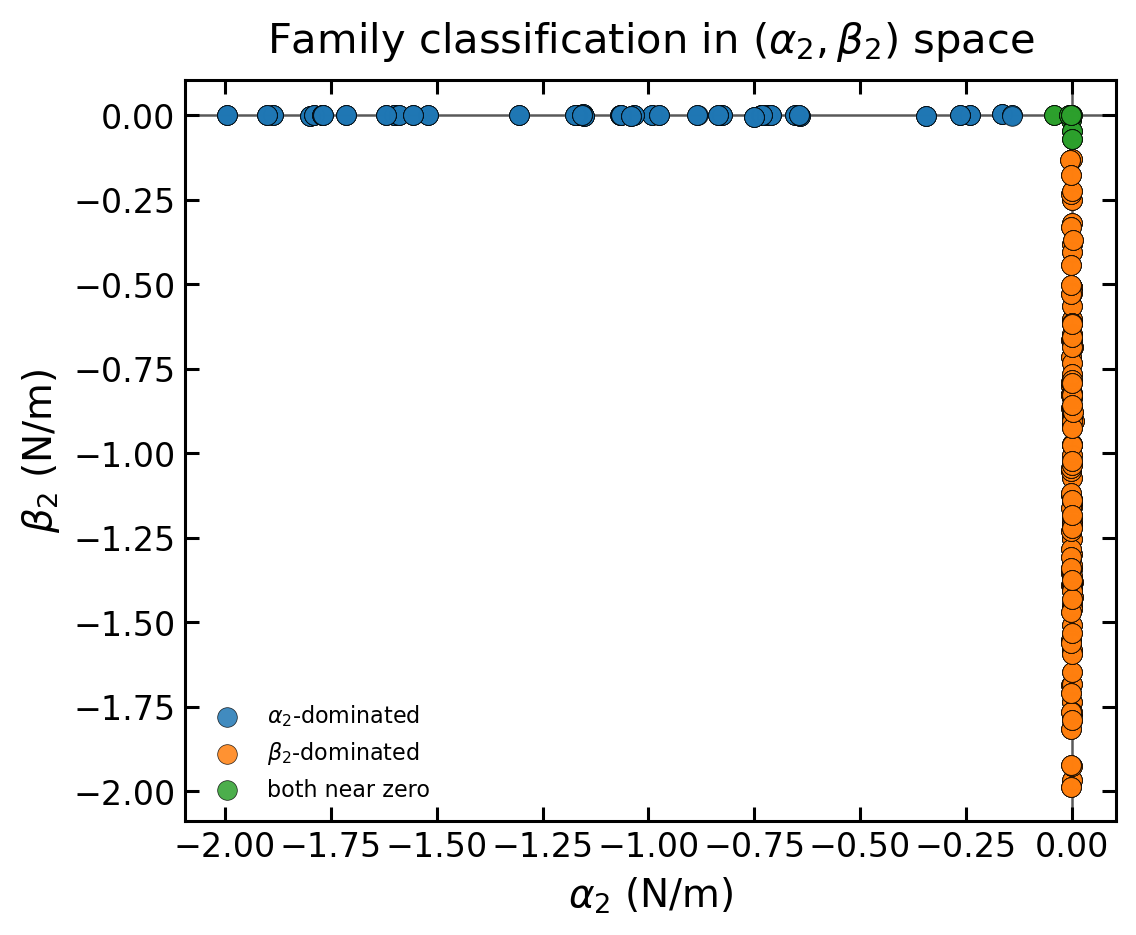

In [11]:
# -----------------------------------------------------------------------------
# Family-colored scatter plot using discrete colors
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=FIGSIZE)

for family in family_order:
    sub = df_top[df_top["family"] == family]
    if sub.empty:
        continue
    ax.scatter(
        sub[alpha2_col],
        sub[beta2_col],
        s=MARKER_SIZE,
        alpha=MARKER_ALPHA,
        edgecolors="black",
        linewidths=EDGE_WIDTH,
        label=family,
    )

ax.axhline(0, color="0.35", linewidth=0.9, zorder=0)
ax.axvline(0, color="0.35", linewidth=0.9, zorder=0)

ax.set_xlabel(display_label(alpha2_col), fontsize=14)
ax.set_ylabel(display_label(beta2_col), fontsize=14)
ax.set_title(r"Family classification in $(\alpha_2,\beta_2)$ space", fontsize=15, pad=10)

apply_publication_axes(ax)
ax.legend(frameon=False, fontsize=8, loc="best")

fig.tight_layout()
save_figure(fig, "beta2_vs_alpha2_colored_by_family")
plt.show()


Saved:
  alpha2_beta2_family_analysis_top5_overall/fitnessnorm_vs_ralpha2_colored_by_aval.pdf
  alpha2_beta2_family_analysis_top5_overall/fitnessnorm_vs_ralpha2_colored_by_aval.png


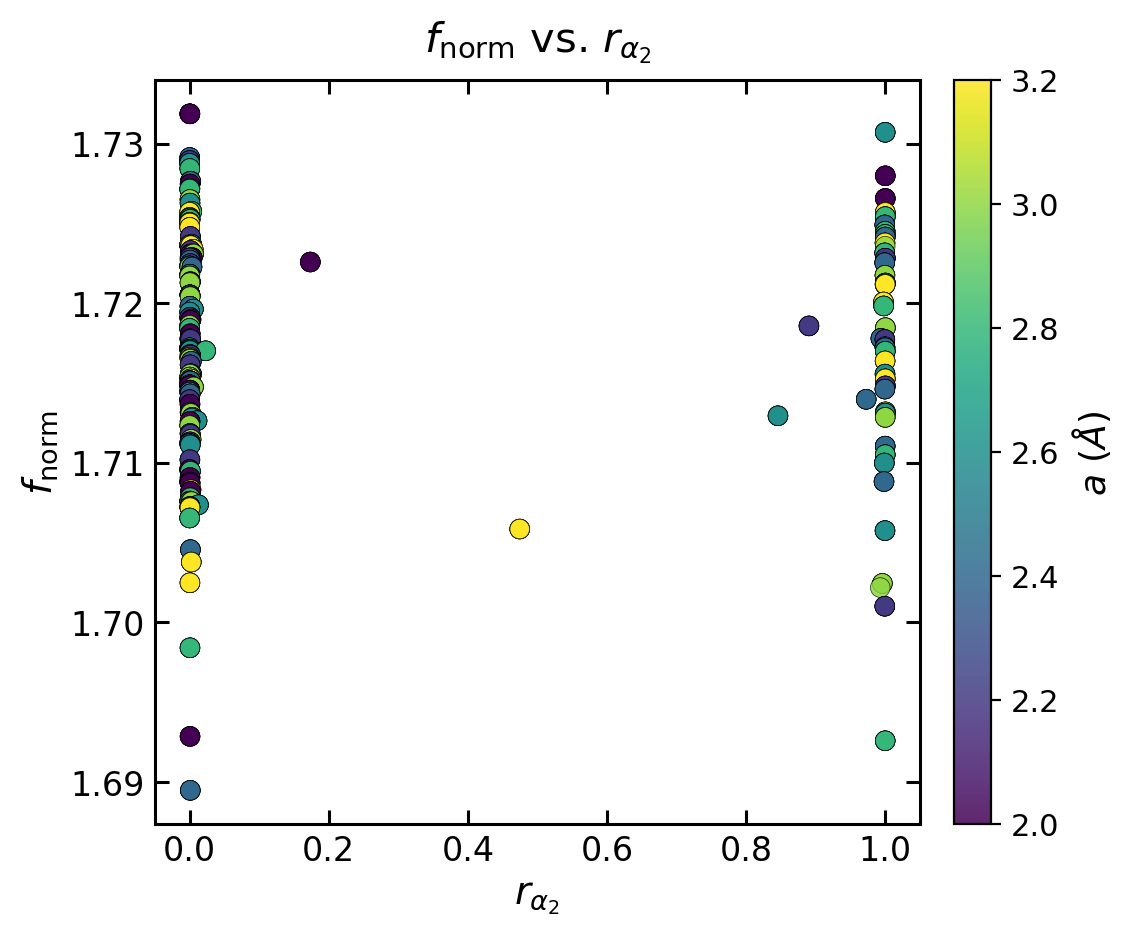

Saved:
  alpha2_beta2_family_analysis_top5_overall/alpha1_vs_ralpha2_colored_by_aval.pdf
  alpha2_beta2_family_analysis_top5_overall/alpha1_vs_ralpha2_colored_by_aval.png


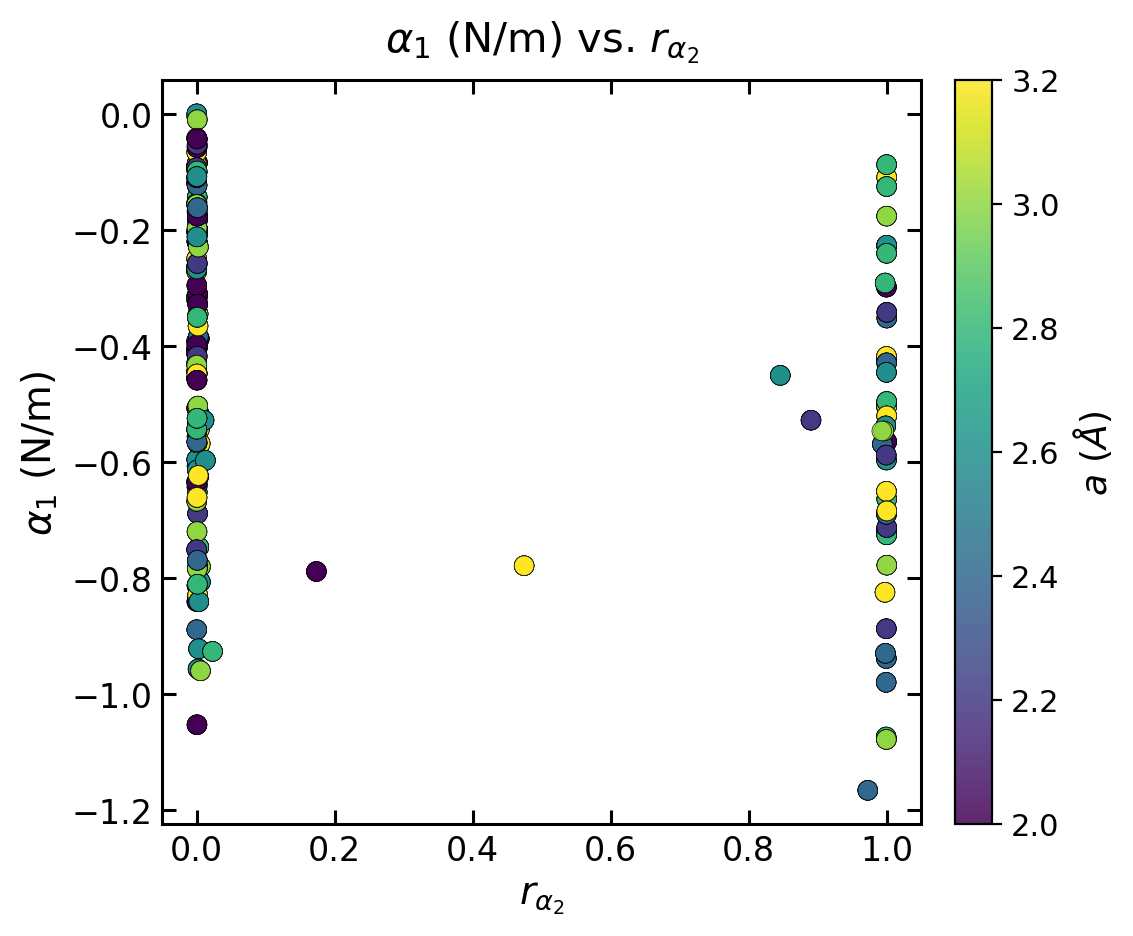

Saved:
  alpha2_beta2_family_analysis_top5_overall/mass_vs_ralpha2_colored_by_aval.pdf
  alpha2_beta2_family_analysis_top5_overall/mass_vs_ralpha2_colored_by_aval.png


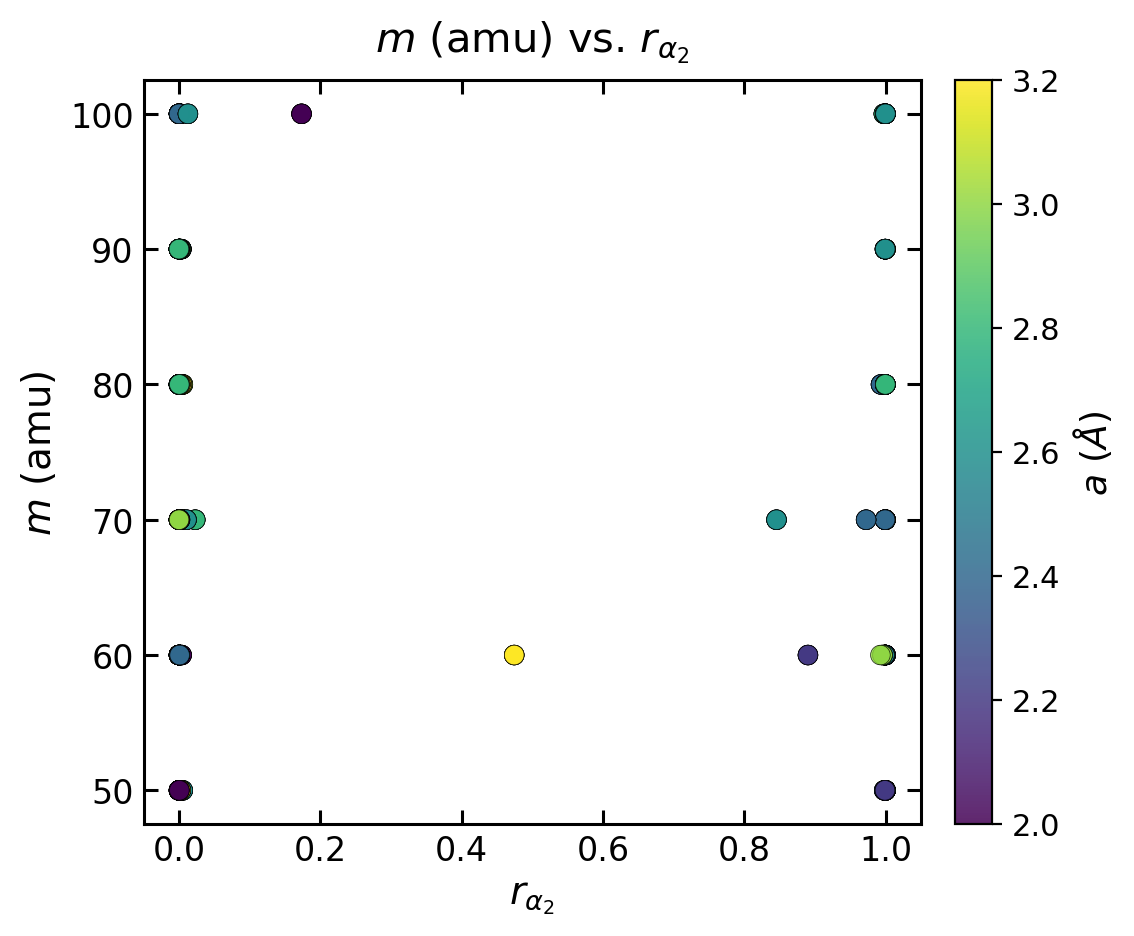

Saved:
  alpha2_beta2_family_analysis_top5_overall/aval_vs_ralpha2_colored_by_aval.pdf
  alpha2_beta2_family_analysis_top5_overall/aval_vs_ralpha2_colored_by_aval.png


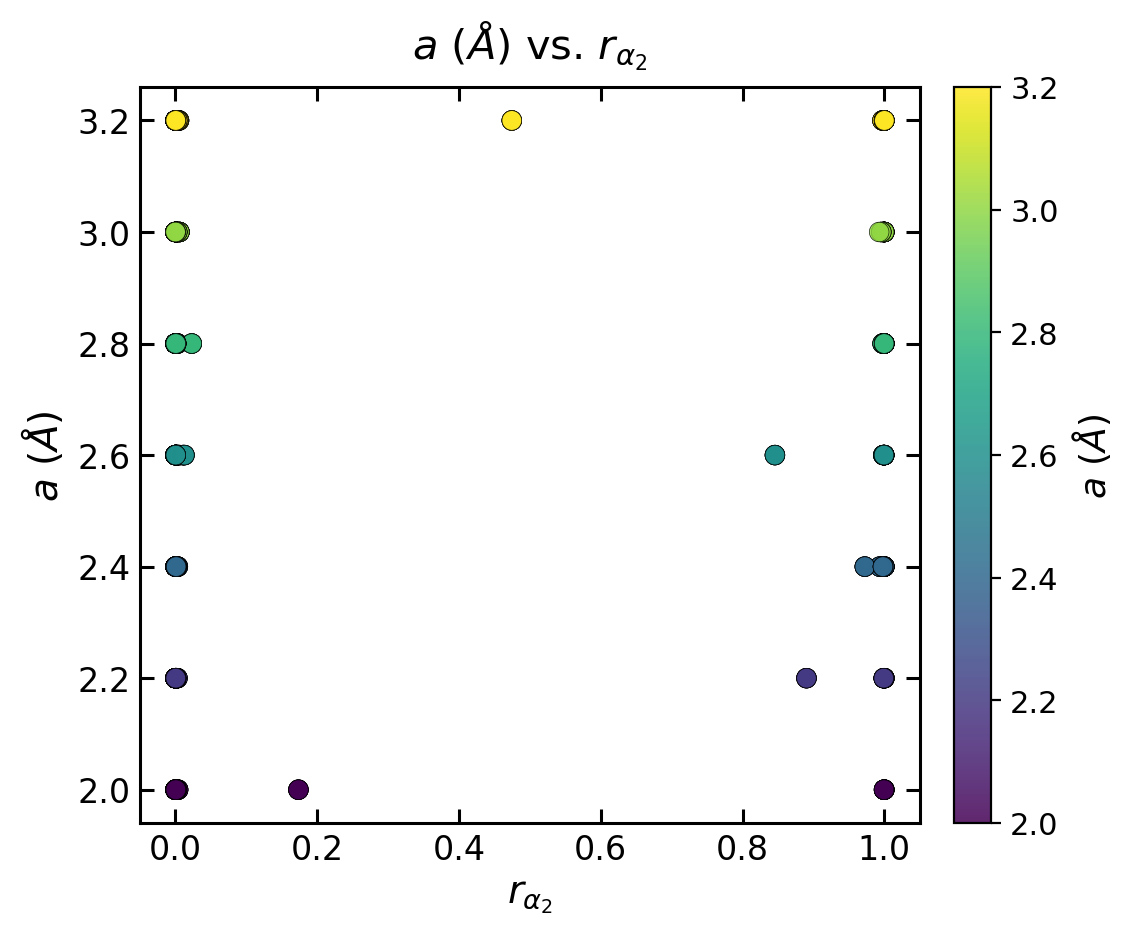

Saved:
  alpha2_beta2_family_analysis_top5_overall/fitnessnorm_vs_deltaalpha2beta2_colored_by_aval.pdf
  alpha2_beta2_family_analysis_top5_overall/fitnessnorm_vs_deltaalpha2beta2_colored_by_aval.png


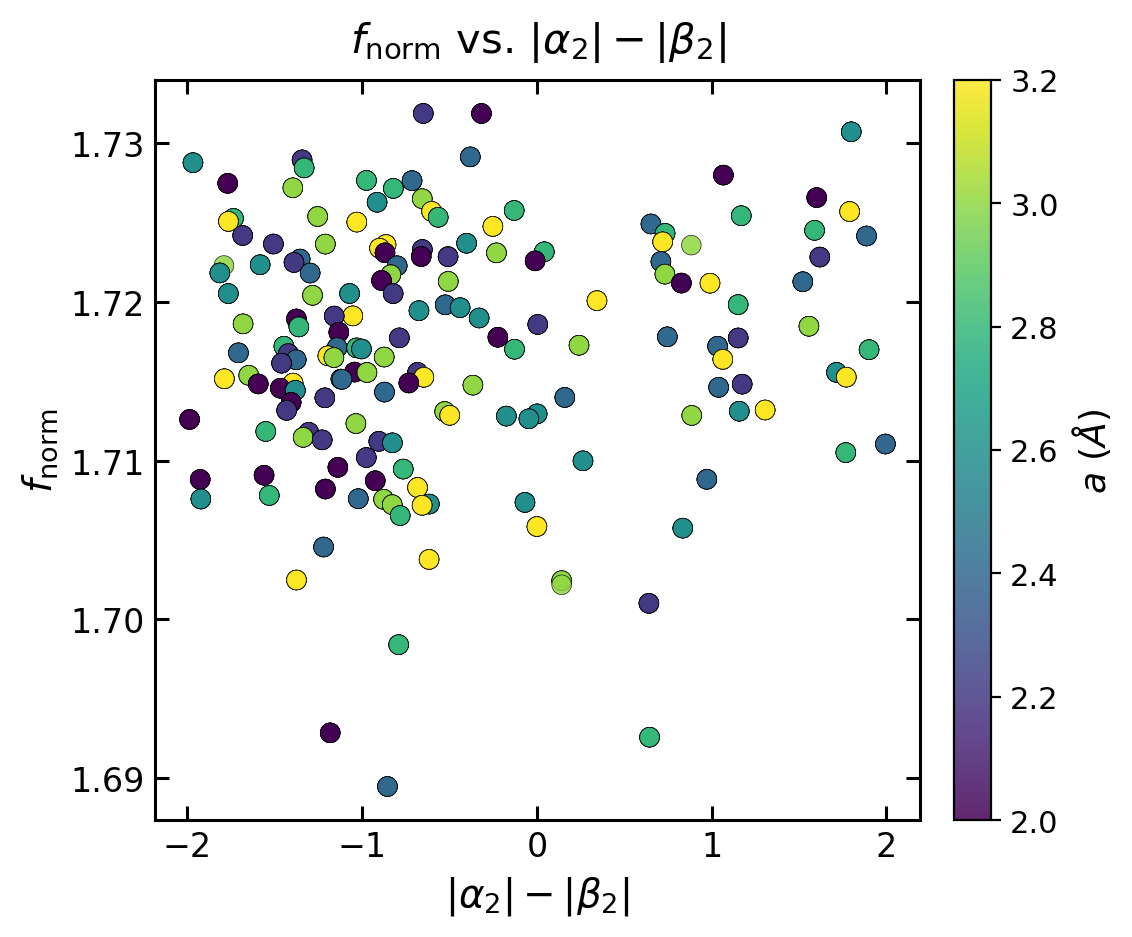

Saved:
  alpha2_beta2_family_analysis_top5_overall/alpha1_vs_deltaalpha2beta2_colored_by_aval.pdf
  alpha2_beta2_family_analysis_top5_overall/alpha1_vs_deltaalpha2beta2_colored_by_aval.png


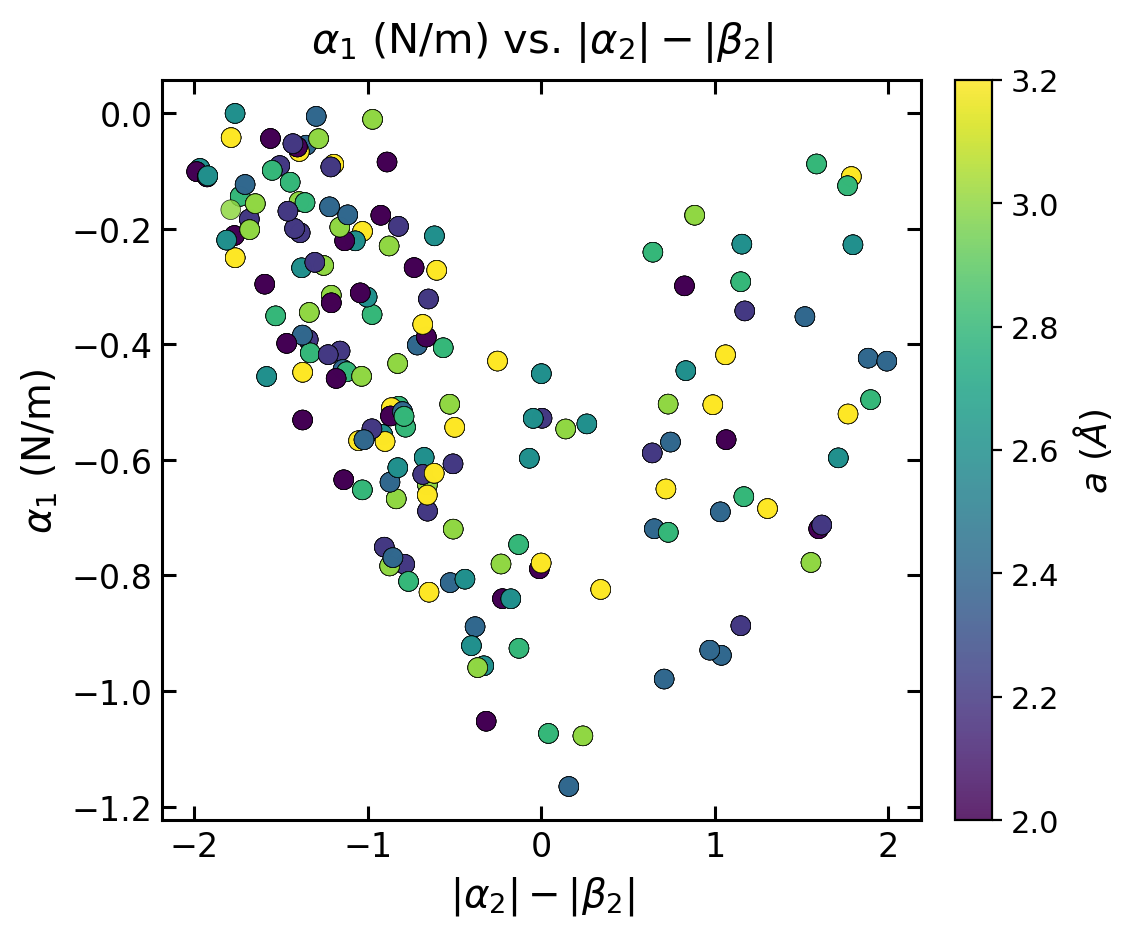

In [12]:
# -----------------------------------------------------------------------------
# Additional diagnostic plots for the two-family interpretation
# -----------------------------------------------------------------------------

diagnostic_pairs = [
    ("r_alpha2", rank_col),
    ("r_alpha2", alpha1_col),
    ("r_alpha2", mass_col),
    ("r_alpha2", alat_col),
    ("delta_alpha2_beta2", rank_col),
    ("delta_alpha2_beta2", alpha1_col),
]

for x_col, y_col in diagnostic_pairs:
    fig, ax = plt.subplots(figsize=FIGSIZE)

    sc = ax.scatter(
        df_top[x_col],
        df_top[y_col],
        c=df_top[alat_col],
        cmap="viridis",
        s=MARKER_SIZE,
        alpha=MARKER_ALPHA,
        edgecolors="black",
        linewidths=EDGE_WIDTH,
    )

    ax.set_xlabel(display_label(x_col), fontsize=14)
    ax.set_ylabel(display_label(y_col), fontsize=14)
    ax.set_title(f"{display_label(y_col)} vs. {display_label(x_col)}", fontsize=15, pad=10)

    apply_publication_axes(ax)

    cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(display_label(alat_col), fontsize=13)
    cbar.ax.tick_params(labelsize=11)

    fig.tight_layout()
    stem = f"{safe_token(y_col)}_vs_{safe_token(x_col)}_colored_by_{safe_token(alat_col)}"
    save_figure(fig, stem)

    plt.show()


In [13]:
# -----------------------------------------------------------------------------
# Save the analyzed top-5 dataset
# -----------------------------------------------------------------------------

csv_path = OUTPUT_DIR / "top5_overall_alpha2_beta2_family_analysis.csv"
df_top.to_csv(csv_path, index=False)
print(f"Saved analyzed dataset: {csv_path}")


Saved analyzed dataset: alpha2_beta2_family_analysis_top5_overall/top5_overall_alpha2_beta2_family_analysis.csv


## Suggested interpretation

The key quantity

\[
r_{\alpha_2}
=
\frac{|\alpha_2|}
{|\alpha_2|+|\beta_2|}
\]

is close to 1 for \(\alpha_2\)-dominated solutions and close to 0 for \(\beta_2\)-dominated solutions. The quantity

\[
\Delta_{\alpha_2,\beta_2}=|\alpha_2|-|\beta_2|
\]

is positive for \(\alpha_2\)-dominated solutions and negative for \(\beta_2\)-dominated solutions.

If the scatter plot shows two branches, one near \(\beta_2=0\) and one near \(\alpha_2=0\), the top-ranked solutions can be interpreted as two distinct families of second-nearest-neighbor force-constant parameterizations.
